# The Same Network, in PyTorch

A line-by-line counterpart to [`basic_neural_net.ipynb`](basic_neural_net.ipynb),
which built a two-layer digit classifier in pure NumPy with every gradient
derived by hand.

**Only one thing changes here: the framework.** Same architecture, same 7,960
parameters, same data, same 80/20 split, same learning rate, same 1,000
full-batch iterations. 

## What PyTorch takes over

| In the NumPy notebook | Here |
|---|---|
| `initialize_parameters` | `nn.Linear` constructs and initializes |
| `ReLU`, `softmax`, `forward_propagation` | `nn.Module.forward` |
| `one_hot` + `cross_entropy_loss` | `nn.CrossEntropyLoss` |
| `backward_propagation` — six derived equations | `loss.backward()` |
| `update_parameters` | `optimizer.step()` |
| `gradient_check` against finite differences | not needed — but see Section 12 |

Section 12 takes the six equations derived by hand in the first notebook, implements them
in PyTorch, and checks them against what autograd computes. If the derivation
was right, the two agree to floating-point precision, which is a far more
direct confirmation than explicit finite differences.

## Contents

| Section | Topic |
|---|---|
| 1–3 | Setup, the data, and a change of shape convention |
| 4 | The architecture as an `nn.Module` |
| 5 | Forward propagation, and why the output has no softmax |
| 6 | The loss, and the `one_hot` that disappears |
| 7 | Autograd, in place of six equations |
| 8–9 | The optimizer and the training loop |
| 10–11 | Evaluation, and what the hidden layer learned |
| 12 | **Checking autograd against the hand-derived gradients** |

---
## 1. Setup

Two additions to the NumPy notebook's imports: `torch` itself, and
`torch.nn.functional` for the stateless operations.

PyTorch will use a GPU if one is available. For a network this small it makes
little difference, i.e., 7,960 parameters do not keep an accelerator busy. But the
device selection is written out because it is the one piece of boilerplate needed by every
PyTorch program.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt

RNG_SEED = 0
torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"PyTorch {torch.__version__}")
print(f"device: {device}")

PyTorch 2.7.1
device: mps


---
## 2. The data

The same `train.csv`: a path beside the
notebook, a locally synced Google Drive, or a Drive mount inside Colab.

In [2]:
from pathlib import Path

# Where train.csv might live, checked in order.
CANDIDATE_PATHS = [
    Path("data/train.csv"),                                     # next to this notebook
    Path("train.csv"),                                          # same folder
    Path("/content/drive/MyDrive/digit-recognizer/train.csv"),  # Drive, inside Colab
]

# Google Drive for Desktop syncs Drive into a local folder whose exact name
# depends on the account, so we glob for it rather than hard-coding one.
DRIVE_PATTERNS = [
    "My Drive*/digit-recognizer/train.csv",
    "Google Drive*/digit-recognizer/train.csv",
    "Library/CloudStorage/GoogleDrive*/My Drive/digit-recognizer/train.csv",
]


def locate_training_csv():
    """Find train.csv locally, in a synced Google Drive, or by mounting Drive in Colab."""
    for path in CANDIDATE_PATHS:
        if path.exists():
            return path

    for pattern in DRIVE_PATTERNS:
        for path in sorted(Path.home().glob(pattern)):
            return path

    try:
        from google.colab import drive
    except ImportError:
        pass
    else:
        drive.mount("/content/drive")
        for path in CANDIDATE_PATHS:
            if path.exists():
                return path

    raise FileNotFoundError(
        "Could not find train.csv. Download it from "
        "https://www.kaggle.com/competitions/digit-recognizer/data and place it "
        "at one of: " + ", ".join(str(p) for p in CANDIDATE_PATHS)
    )


data = pd.read_csv(locate_training_csv())
print(f"{data.shape[0]} rows x {data.shape[1]} columns")

42000 rows x 785 columns


---
## 3. A change of shape convention

This is the only part of the port that requires care. It is a classic source of confusion.

The NumPy notebook put **examples in columns**:

$$
X \in \mathbb{R}^{784 \times m}, \qquad Z^{[1]} = W^{[1]} X + b^{[1]}
$$

PyTorch puts **examples in rows**, because that is what `nn.Linear`, every
dataset, and every batch dimension assume:

$$
X \in \mathbb{R}^{m \times 784}, \qquad Z^{[1]} = X \left(W^{[1]}\right)^{\!\top} + b^{[1]}
$$

Notice what did *not* change. `nn.Linear(784, 10)` stores its weight with shape
$(\text{out}, \text{in}) = (10, 784)$ — exactly the shape of $W^{[1]}$ in the
first notebook. The matrix is the same; only the side it multiplies from
differs. The hand-derived gradients in Section 12 transpose so
cleanly onto PyTorch's.

The labels also get simpler: they stay as integers. No one-hot encoding is
needed (explained in Section).

In [3]:
data_array = np.array(data)
m_total = data_array.shape[0]

rng = np.random.default_rng(RNG_SEED)
rng.shuffle(data_array)                      # same shuffle as the NumPy notebook
n_train = int(0.8 * m_total)

def to_tensors(rows):
    """(n, 785) array -> (n, 784) float pixels in [0,1] and (n,) integer labels."""
    pixels = torch.tensor(rows[:, 1:] / 255.0, dtype=torch.float32)
    labels = torch.tensor(rows[:, 0], dtype=torch.long)
    return pixels.to(device), labels.to(device)


X_train, Y_train = to_tensors(data_array[:n_train])
X_val, Y_val = to_tensors(data_array[n_train:])

print(f"X_train {tuple(X_train.shape)}   Y_train {tuple(Y_train.shape)}")
print(f"X_val   {tuple(X_val.shape)}    Y_val   {tuple(Y_val.shape)}")
print(f"\nNumPy notebook had X_train as (784, {n_train}) -- the transpose")
print(f"labels stay as integers: {Y_train[:8].tolist()}")

X_train (33600, 784)   Y_train (33600,)
X_val   (8400, 784)    Y_val   (8400,)

NumPy notebook had X_train as (784, 33600) -- the transpose
labels stay as integers: [2, 2, 7, 5, 6, 8, 4, 5]


---
## 4. The architecture

In the NumPy notebook this was `initialize_parameters`, returning four arrays.
Here it is a class, and `nn.Linear` does both the construction and the
initialization.

Assigning a layer to `self` registers its parameters automatically, which is how
`model.parameters()` later finds everything for the optimizer. 

> **The initialization differs.** The NumPy notebook drew every
> parameter from $\mathcal{U}(-0.5, 0.5)$ and noted that a
> scale-aware scheme would be better. `nn.Linear` already uses one: weights come
> from $\mathcal{U}(-1/\sqrt{n_{\text{in}}},\, 1/\sqrt{n_{\text{in}}})$, so a
> layer with 784 inputs gets far smaller initial weights than one with 10. This is applied by default, and it is why the loss
> here starts near $\log 10$ rather than above it.
>
> Set `MATCH_NUMPY_INIT = True` to reproduce the original scheme and compare.

In [4]:
MATCH_NUMPY_INIT = False


class TwoLayerNet(nn.Module):
    """784 -> 10 (ReLU) -> 10. The same network as the NumPy notebook."""

    def __init__(self, n_x=784, n_h=10, n_y=10):
        super().__init__()
        self.fc1 = nn.Linear(n_x, n_h)
        self.fc2 = nn.Linear(n_h, n_y)

        if MATCH_NUMPY_INIT:                      # U(-0.5, 0.5), as in notebook 1
            for layer in (self.fc1, self.fc2):
                nn.init.uniform_(layer.weight, -0.5, 0.5)
                nn.init.uniform_(layer.bias, -0.5, 0.5)

    def forward(self, x):
        z1 = self.fc1(x)        # (m, 10)
        a1 = F.relu(z1)
        return self.fc2(a1)     # (m, 10) raw logits -- no softmax, see Section 6


model = TwoLayerNet().to(device)
print(model)
print()
total = 0
for name, parameter in model.named_parameters():
    print(f"{name:<12} {str(tuple(parameter.shape)):<12} {parameter.numel():>6,}")
    total += parameter.numel()
print(f"{'total':<12} {'':<12} {total:>6,}")
print(f"\nNumPy notebook: 7,960 parameters")

TwoLayerNet(
  (fc1): Linear(in_features=784, out_features=10, bias=True)
  (fc2): Linear(in_features=10, out_features=10, bias=True)
)

fc1.weight   (10, 784)     7,840
fc1.bias     (10,)            10
fc2.weight   (10, 10)        100
fc2.bias     (10,)            10
total                      7,960

NumPy notebook: 7,960 parameters


---
## 5. Forward propagation

The whole of `forward_propagation` collapses into three lines of `forward`. Two
differences from the NumPy version are worth naming.

**No cached intermediates.** The NumPy function returned $Z^{[1]}, A^{[1]},
Z^{[2]}, A^{[2]}$ because backpropagation needed them. PyTorch records them
automatically as it builds the computation graph, so `forward` returns only
what the caller wants.

**No softmax.** The NumPy notebook applied softmax at the end of the forward
pass. Here `forward` returns raw logits, because `nn.CrossEntropyLoss` applies
the softmax internally. Applying it yourself and passing probabilities to the
loss is a common (and silent) bug: the model still trains, just
worse, because the softmax gets applied twice.

In [5]:
with torch.no_grad():
    logits = model(X_train[:4])

print(f"input  {tuple(X_train[:4].shape)}")
print(f"logits {tuple(logits.shape)}")
print(f"\nraw logits (not probabilities):\n{logits[0]}")
print(f"\nafter softmax, for illustration only:\n{logits[0].softmax(0)}")
print(f"sums to {logits[0].softmax(0).sum():.6f}")

input  (4, 784)
logits (4, 10)

raw logits (not probabilities):
tensor([-0.0611, -0.1877,  0.1168,  0.2805,  0.2205, -0.1409,  0.1272,  0.0123,
         0.3223, -0.2994], device='mps:0')

after softmax, for illustration only:
tensor([0.0887, 0.0782, 0.1060, 0.1249, 0.1176, 0.0819, 0.1071, 0.0955, 0.1302,
        0.0699], device='mps:0')
sums to 1.000000


---
## 6. The loss, and the `one_hot` that disappears

The NumPy notebook needed two functions here: `one_hot` to turn integer labels
into $10 \times m$ indicator columns, and `cross_entropy_loss` to compare them
against the predicted distribution.

`nn.CrossEntropyLoss` replaces both. It takes **raw logits and integer labels**,
and internally does `log_softmax` followed by a negative log-likelihood — which
is mathematically what the NumPy notebook's Section 6 derived, fused into one
numerically stable operation.

The fusion is important. Computing $\log \sum_j e^{z_j}$ naively
overflows for large logits; fusing the two steps lets PyTorch apply the
log-sum-exp shift internally, which is the same trick the NumPy notebook applied
by hand in its Section 5.3.

A useful sanity check: an untrained network should be near chance, and chance
for ten classes costs $-\log(1/10) = \log 10 \approx 2.303$.

In [6]:
criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    initial_loss = criterion(model(X_train), Y_train)

print(f"loss at initialization: {initial_loss:.4f}")
print(f"chance (log 10):        {np.log(10):.4f}")
print(f"\nno one-hot needed; labels are integers: {Y_train[:6].tolist()}")

loss at initialization: 2.3307
chance (log 10):        2.3026

no one-hot needed; labels are integers: [2, 2, 7, 5, 6, 8]


---
## 7. Autograd, in place of six equations

This section replaces the entire derivation of the NumPy notebook's Section 7.

Every tensor with `requires_grad=True` — which includes all model parameters —
records the operation that produced it. The forward pass builds a directed
acyclic graph of those operations, and `loss.backward()` walks it in reverse,
applying the chain rule and accumulating the result in each parameter's `.grad`.

The rules being applied are exactly the ones derived by hand. Our
$dZ^{[2]} = A^{[2]} - Y$ is what autograd computes through `CrossEntropyLoss`;
the ReLU mask $\mathbb{1}[Z^{[1]} > 0]$ is what it computes through `F.relu`. 

**One behaviour surprises everyone.** `.backward()` *adds* to `.grad` rather
than overwriting it, so gradients from successive passes accumulate. Hence
`optimizer.zero_grad()` before each backward pass. This is deliberate: it lets
us simulate a large batch by summing gradients over several forward passes. It
just means the zeroing is our responsibility.

In [7]:
probe = TwoLayerNet().to(device)
print("grad before any backward pass:", probe.fc1.bias.grad)

loss = criterion(probe(X_train[:256]), Y_train[:256])
loss.backward()
first = probe.fc1.bias.grad.clone()
print(f"after one backward:  {first[:3].tolist()}")

loss = criterion(probe(X_train[:256]), Y_train[:256])
loss.backward()                                    # no zero_grad -- accumulates
second = probe.fc1.bias.grad.clone()
print(f"after a second:      {second[:3].tolist()}")
print(f"exactly doubled:     {torch.allclose(second, 2 * first)}")

probe.zero_grad(set_to_none=False)
print(f"after zero_grad:     {probe.fc1.bias.grad[:3].tolist()}")

grad before any backward pass: None
after one backward:  [-0.004001842811703682, 0.015030787326395512, -0.002902013948187232]
after a second:      [-0.008003685623407364, 0.030061574652791023, -0.005804027896374464]
exactly doubled:     True
after zero_grad:     [0.0, 0.0, 0.0]


---
## 8. The update rule

The NumPy notebook's `update_parameters` applied

$$
\theta \;\leftarrow\; \theta - \alpha \,\frac{\partial \mathcal{L}}{\partial \theta}
$$

once per parameter, in four explicit lines. `torch.optim.SGD` does the same
thing for every registered parameter, and `model.parameters()` is how it knows
which those are.

We keep $\alpha = 0.5$, the value the NumPy notebook used.

In [8]:
LEARNING_RATE = 0.5
ITERATIONS = 1000

model = TwoLayerNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
print(optimizer)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.5
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


---
## 9. Training

The NumPy notebook computed the gradient over all 33,600 training images before
every step — **full-batch gradient descent** — and ran 1,000 such steps. We do
exactly the same here, rather than switching to mini-batches, so the comparison
stays honest. Mini-batching is introduced in `cnn_pytorch.ipynb`.

Each iteration is the same three steps, in the same order:

| | NumPy notebook | Here |
|---|---|---|
| forward | `forward_propagation(...)` | `model(X_train)` |
| loss | `cross_entropy_loss(...)` | `criterion(logits, Y_train)` |
| backward | `backward_propagation(...)` | `loss.backward()` |
| update | `update_parameters(...)` | `optimizer.step()` |

with `optimizer.zero_grad()` in front, for the accumulation reason above.

In [9]:
import time


@torch.no_grad()
def accuracy(model, X, Y):
    model.eval()
    return (model(X).argmax(dim=1) == Y).float().mean().item()


history = {"iteration": [], "loss": [], "accuracy": []}
started = time.time()

for i in range(ITERATIONS):
    model.train()
    optimizer.zero_grad()                       # gradients accumulate; clear them
    logits = model(X_train)                     # forward
    loss = criterion(logits, Y_train)           # loss
    loss.backward()                             # backward  (autograd)
    optimizer.step()                            # update

    if i % 20 == 0 or i == ITERATIONS - 1:
        with torch.no_grad():
            train_acc = (logits.argmax(dim=1) == Y_train).float().mean().item()
        history["iteration"].append(i)
        history["loss"].append(loss.item())
        history["accuracy"].append(train_acc)
        if i % 100 == 0:
            print(f"iteration {i:5d}   loss {loss.item():.4f}   "
                  f"training accuracy {train_acc:.4f}")

print(f"\ntrained in {time.time() - started:.1f}s")

iteration     0   loss 2.3163   training accuracy 0.1181
iteration   100   loss 0.3767   training accuracy 0.8888
iteration   200   loss 0.3081   training accuracy 0.9110
iteration   300   loss 0.2749   training accuracy 0.9213
iteration   400   loss 0.2702   training accuracy 0.9215
iteration   500   loss 0.8356   training accuracy 0.7380
iteration   600   loss 0.2415   training accuracy 0.9299
iteration   700   loss 0.2335   training accuracy 0.9320
iteration   800   loss 0.2268   training accuracy 0.9349
iteration   900   loss 0.2187   training accuracy 0.9372

trained in 4.2s


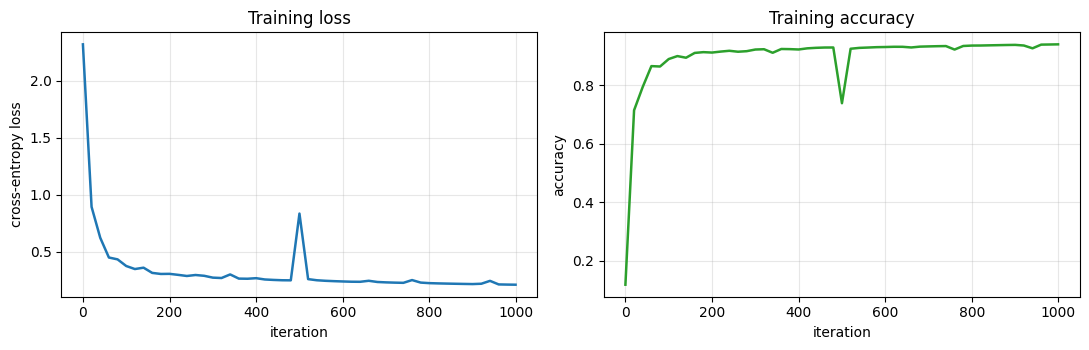

In [10]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 3.6))

ax_loss.plot(history["iteration"], history["loss"], lw=1.8)
ax_loss.set_xlabel("iteration"); ax_loss.set_ylabel("cross-entropy loss")
ax_loss.set_title("Training loss"); ax_loss.grid(alpha=0.3)

ax_acc.plot(history["iteration"], history["accuracy"], lw=1.8, color="tab:green")
ax_acc.set_xlabel("iteration"); ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Training accuracy"); ax_acc.grid(alpha=0.3)

plt.tight_layout(); plt.show()

You may see the loss spike sharply at some point and then recover within a few
iterations. That is a consequence of holding $\alpha = 0.5$
fixed while changing the initialization.

The NumPy notebook's $\mathcal{U}(-0.5, 0.5)$ weights produced large
activations and correspondingly small, well-conditioned gradient steps.
`nn.Linear`'s smaller weights put the network in a sharper region of the loss
surface, where a learning rate of 0.5 is occasionally too large and a single
step overshoots. Full-batch descent then recovers, because the next gradient
points firmly back.

It is a good illustration that a learning rate is not a property of the problem
alone. It interacts with the initialization, and a value that was safe under
one scheme can be marginal under another. Lowering $\alpha$ to 0.1, or
switching to Adam, removes the spikes entirely.

---
## 10. Evaluation

In [11]:
train_accuracy = accuracy(model, X_train, Y_train)
val_accuracy = accuracy(model, X_val, Y_val)

print(f"training accuracy:   {train_accuracy:.4f}")
print(f"validation accuracy: {val_accuracy:.4f}")
print(f"\nNumPy notebook reached 0.9081 validation accuracy")

training accuracy:   0.9385
validation accuracy: 0.9265

NumPy notebook reached 0.9081 validation accuracy


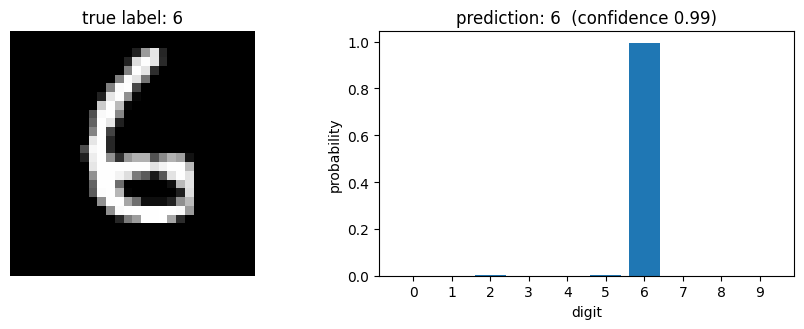

In [12]:
val_index = 500

model.eval()
with torch.no_grad():
    probabilities = model(X_val[val_index:val_index + 1]).softmax(dim=1)[0].cpu()

fig, (ax_image, ax_bars) = plt.subplots(1, 2, figsize=(9, 3.4))
ax_image.imshow(X_val[val_index].cpu().reshape(28, 28), cmap="gray")
ax_image.set_title(f"true label: {Y_val[val_index].item()}")
ax_image.axis("off")

ax_bars.bar(np.arange(10), probabilities.numpy())
ax_bars.set_xticks(np.arange(10))
ax_bars.set_xlabel("digit"); ax_bars.set_ylabel("probability")
ax_bars.set_title(f"prediction: {probabilities.argmax().item()}  "
                  f"(confidence {probabilities.max():.2f})")
plt.tight_layout(); plt.show()

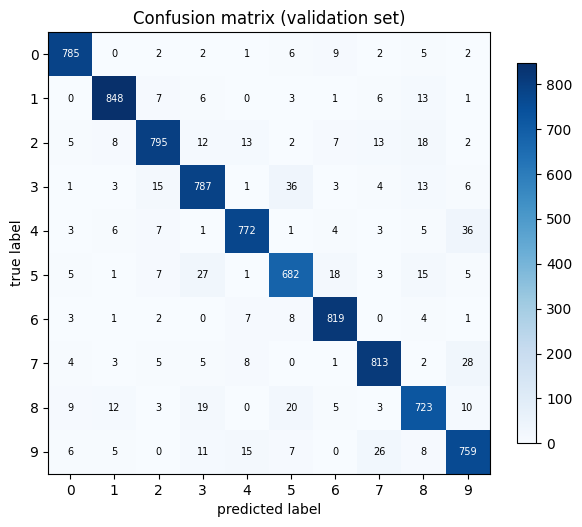

In [13]:
with torch.no_grad():
    val_predictions = model(X_val).argmax(dim=1)

confusion = torch.zeros(10, 10, dtype=torch.long)
for true_label, predicted in zip(Y_val.cpu(), val_predictions.cpu()):
    confusion[true_label, predicted] += 1

fig, ax = plt.subplots(figsize=(6.2, 5.4))
image = ax.imshow(confusion, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("predicted label"); ax.set_ylabel("true label")
ax.set_title("Confusion matrix (validation set)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, confusion[i, j].item(), ha="center", va="center", fontsize=7,
                color="white" if confusion[i, j] > confusion.max() / 2 else "black")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

---
## 11. What did the hidden layer learn?

`fc1.weight` has shape $(10, 784)$ — the same shape as $W^{[1]}$ in the NumPy
notebook — so each row reshapes to a $28 \times 28$ image showing what that
hidden unit responds to.

The NumPy notebook found the learned structure buried under its
$\mathcal{U}(-0.5, 0.5)$ initialization and had to subtract the initial weights
to reveal it. That is not necessary here: `nn.Linear` starts with weights around
$\pm 1/\sqrt{784} \approx \pm 0.036$, an order of magnitude smaller, so training
moves them far more than their starting noise and the structure is visible
directly. A concrete payoff from better initialization.

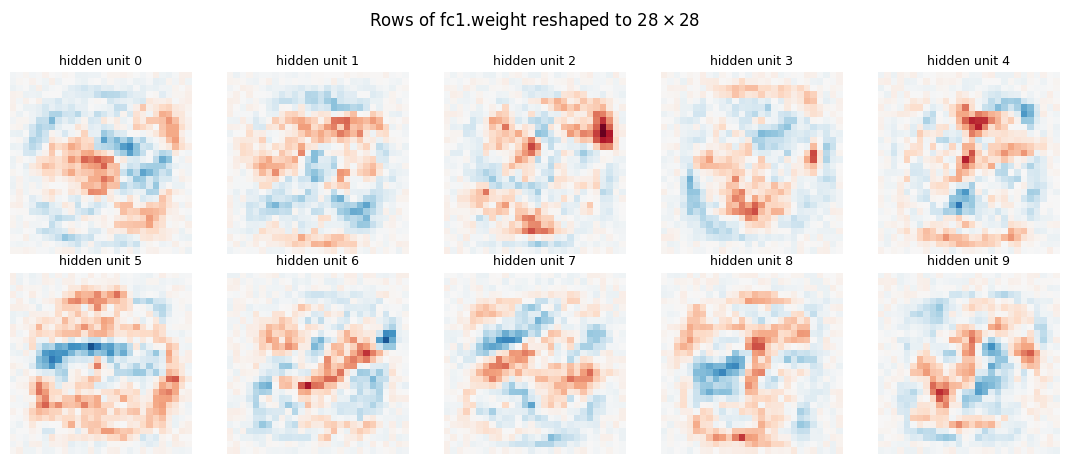

initial weight scale ~ 1/sqrt(784) = 0.0357
trained weight std           = 0.0925


In [14]:
weights = model.fc1.weight.detach().cpu()
limit = weights.abs().max()

fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for unit, ax in enumerate(axes.flat):
    ax.imshow(weights[unit].reshape(28, 28), cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(f"hidden unit {unit}", fontsize=9)
    ax.axis("off")
fig.suptitle(r"Rows of fc1.weight reshaped to $28 \times 28$", y=1.0)
plt.tight_layout(); plt.show()

print(f"initial weight scale ~ 1/sqrt(784) = {1/np.sqrt(784):.4f}")
print(f"trained weight std           = {weights.std():.4f}")

---
## 12. Checking autograd against the hand-derived gradients

The NumPy notebook derived six equations by hand and verified them against
centred finite differences. Here we implement **those same
equations** in PyTorch and check them against what autograd produced. If the
derivation was correct, the two must agree to floating-point precision.

The equations, transposed for row-major examples. With $X \in \mathbb{R}^{m
\times 784}$ and one-hot targets $Y \in \mathbb{R}^{m \times 10}$:

$$
\begin{aligned}
dZ^{[2]} &= A^{[2]} - Y \\
dW^{[2]} &= \tfrac{1}{m}\, \left(dZ^{[2]}\right)^{\!\top} A^{[1]} \\
db^{[2]} &= \tfrac{1}{m}\, \textstyle\sum_i dz^{[2](i)} \\
dZ^{[1]} &= dZ^{[2]} W^{[2]} \odot \mathbb{1}\!\left[Z^{[1]} > 0\right] \\
dW^{[1]} &= \tfrac{1}{m}\, \left(dZ^{[1]}\right)^{\!\top} X \\
db^{[1]} &= \tfrac{1}{m}\, \textstyle\sum_i dz^{[1](i)}
\end{aligned}
$$

Compare against the NumPy notebook's Section 7.4: every transpose has moved to
the other side, which is precisely what the column-to-row convention change
predicts. The mathematics is identical.

In [15]:
check_model = TwoLayerNet().to(device)
X, Y = X_train[:512], Y_train[:512]
m = X.shape[0]

# --- what autograd computes --------------------------------------------------
check_model.zero_grad()
criterion(check_model(X), Y).backward()
autograd = {name: p.grad.clone() for name, p in check_model.named_parameters()}

# --- the same six equations, by hand -----------------------------------------
with torch.no_grad():
    W1, b1 = check_model.fc1.weight, check_model.fc1.bias
    W2, b2 = check_model.fc2.weight, check_model.fc2.bias

    Z1 = X @ W1.T + b1                       # (m, 10)
    A1 = torch.clamp(Z1, min=0)              # ReLU
    Z2 = A1 @ W2.T + b2                      # (m, 10)
    A2 = Z2.softmax(dim=1)

    Y_onehot = F.one_hot(Y, num_classes=10).float()

    dZ2 = A2 - Y_onehot                      # the softmax/cross-entropy shortcut
    dW2 = dZ2.T @ A1 / m
    db2 = dZ2.sum(dim=0) / m
    dZ1 = (dZ2 @ W2) * (Z1 > 0)              # through W2, then the ReLU mask
    dW1 = dZ1.T @ X / m
    db1 = dZ1.sum(dim=0) / m

by_hand = {"fc1.weight": dW1, "fc1.bias": db1, "fc2.weight": dW2, "fc2.bias": db2}

print(f"{'parameter':<14}{'max abs difference':>20}{'relative':>14}   verdict")
for name in autograd:
    a, h = autograd[name], by_hand[name]
    absolute = (a - h).abs().max().item()
    relative = absolute / (a.abs().max().item() + 1e-12)
    print(f"{name:<14}{absolute:>20.3e}{relative:>14.3e}   "
          f"{'MATCH' if relative < 1e-5 else 'DIFFERS'}")

parameter       max abs difference      relative   verdict
fc1.weight               3.725e-09     9.415e-08   MATCH
fc1.bias                 4.657e-09     1.795e-07   MATCH
fc2.weight               3.725e-09     1.890e-07   MATCH
fc2.bias                 1.304e-08     2.898e-07   MATCH


If those relative differences are at the level of floating-point round-off, two
things are established at once: the derivation in the first notebook was
correct, and autograd is applying the same chain rule rather than approximating
anything.

That is a stronger statement than the finite-difference check. Finite
differences confirm a gradient is *plausible* to within $O(\varepsilon^2)$;
this confirms two independent implementations of the same derivation agree.

It is also the practical reason to trust autograd on networks too complicated to
differentiate by hand.

---
## 13. Summary

### What changed, and what did not

| | NumPy notebook | This notebook |
|---|---|---|
| Lines to define the model | ~30 | 8 |
| Lines for the backward pass | ~15, derived | 1 |
| Architecture | 784 → 10 → 10 | identical |
| Parameters | 7,960 | identical |
| Optimizer | hand-written SGD | `torch.optim.SGD`, same rule |
| Iterations | 1,000 full-batch | identical |

The mathematics did not move. It went behind an interface. Everything in the
right-hand column is doing what the left-hand column spelled out, which is why
Section 12 can compare them directly.

The accuracy may differ slightly, and the reason is initialization rather than
the framework: `nn.Linear` scales by $1/\sqrt{n_{\text{in}}}$ where the NumPy
notebook used a fixed $\mathcal{U}(-0.5, 0.5)$. Set `MATCH_NUMPY_INIT = True`
in Section 4 to remove even that difference.
